# Model usage
This script is dedicated to loading the size invariant saliency prediction model described in our previous presentations, as well as our paper.
It is part of the module "Human-Computer Interfaces" at the university of Leipzig, taught by Patrick Ebel.

The used dataset can be found here: <br>
https://github.com/YueJiang-nj/UEyes-CHI2023

For the dataset we will be using the saliency heatmaps from the folder "heatmaps_1s" and "heatmaps_3s". <br>
(And the basic images from the image folder.)

The implementation is consists of 3 steps:
1. Defining the necessary functions and structures.
2. Loading the model weights from a checkpoint.
3. Defining a full pipeline function, that returns the output image to any provided input.

### 0. Imports

In [1]:
import os
import timm
import torch
import random
import pandas
import patchify
import numpy as np
from PIL import Image, ImageFilter
import torch.nn as nn
from matplotlib import pyplot
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

C:\Users\Core\miniconda3\envs\thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Defining necessary functions / structures

### 1.1 Importing the Data
Loading in all the images from their folders. <br>
Splitting them into a train / test split. <br>
Removing overly large images.

In [2]:
# Define the paths to the dataset:
# (Only works in Jupyter Notebook)
# [ATTENTION]: MODIFY THESE PATHS IF YOUR IMAGES AND TARGETS ARE LOCATED ELSEWHERE
script_directory = os.getcwd()
image_directory = os.path.join(script_directory, "dataset", "images")
target_directory = os.path.join(script_directory, "dataset", "heatmaps_1s")
list_path = os.path.join(script_directory, "image_types.csv")

In [3]:
def select_dataset(image_type, list_path):
# This function extracts all image names of a certain category from the csv at the provided location.
# (It is a helper function for our specific use case, does not apply in general.)

    if image_type == "all":
    # Select all names if "all" is specified:
        
        dataset_list = os.listdir(image_directory)
        return dataset_list

    else:
    # Select all names with the specified category otherwise:
        
        dataset_list = pandas.read_csv(list_path, sep = ";")
        dataset_list = dataset_list[dataset_list['Category'] == image_type]
        dataset_list = dataset_list['Image Name']
        dataset_list = dataset_list.tolist()
        
        return dataset_list

    return dataset_list

In [4]:
# Create name lists for all images of a certain category:
# (all, desktop, mobile, poster, web)
all_name_list = select_dataset("all", list_path)
desktop_name_list = select_dataset("desktop", list_path)
mobile_name_list = select_dataset("mobile", list_path)
poster_name_list = select_dataset("poster", list_path)
web_name_list = select_dataset("web", list_path)

print(f'There are {len(all_name_list)} images of category {"all"} in the dataset.')
print(f'There are {len(desktop_name_list)} images of category {"desktop"} in the dataset.')
print(f'There are {len(mobile_name_list)} images of category {"mobile"} in the dataset.')
print(f'There are {len(poster_name_list)} images of category {"poster"} in the dataset.')
print(f'There are {len(web_name_list)} images of category {"web"} in the dataset.')

There are 1980 images of category all in the dataset.
There are 495 images of category desktop in the dataset.
There are 495 images of category mobile in the dataset.
There are 495 images of category poster in the dataset.
There are 495 images of category web in the dataset.


In [5]:
# Getting the lists for train and test:
# (We decided on a 80/20 train-test-split since the dataset is somewhat small.)
# (So we assume that more training examples will benefit us more than the reduced test variance.)
shuffle_seed = 36
training_ratio = 0.8

# Deterministic shuffling:
# [ATTENTION]: Specify your wanted category here.
image_name_list = all_name_list
random.seed(shuffle_seed)
random.shuffle(image_name_list)

train_test_split = int(training_ratio * len(image_name_list))

train_names = image_name_list[:train_test_split]
test_names = image_name_list[train_test_split:]

In [6]:
def load_images(file_path, file_names):
# The function tries to load all images in the list "file_names" from the folder "file_path".

    image_set = []
    
    for name in file_names:
        image_path = os.path.join(file_path, name)
        loaded_image = Image.open(image_path)
        image_set.append(loaded_image)

    return image_set

In [7]:
# Load the different sets of data:
train_images = load_images(image_directory, train_names)
train_targets = load_images(target_directory, train_names)
print("Finished loading the training sets.")

test_images = load_images(image_directory, test_names)
test_targets = load_images(target_directory, test_names)
print("Finished loading the test sets.")

Finished loading the training sets.
Finished loading the test sets.


In [8]:
def remove_large_images(image_list, pixel_limit):
# The function detects images with heights / widths over the pixel limit.
# It returns the reduced image list and prints the number of images removed.
    removed_images = 0
    filtered_list = []
    
    for image in image_list:

        if image.size[0] >= pixel_limit or image.size[1] >= pixel_limit:

            removed_images += 1

        else:

            filtered_list.append(image)

    print(f"A total of {removed_images} images have been removed.")
    return filtered_list

In [9]:
# Very large images blow up calculation time due to drastically heightened patch-count.
# Since the number of images of this type in the dataset is negligeble we decided to remove them.
pixel_limit = 3000

train_images = remove_large_images(train_images, pixel_limit)
train_targets = remove_large_images(train_targets, pixel_limit)

test_images = remove_large_images(test_images, pixel_limit)
test_targets = remove_large_images(test_targets, pixel_limit)

A total of 22 images have been removed.
A total of 22 images have been removed.
A total of 7 images have been removed.
A total of 7 images have been removed.


### 1.2 Pre-Processing
Pre-Processing contains the following steps:
- Padding
- Patching
- Flattening\*
- Normalization\*\*
- Positional Encoding

\* Original dimensions of the picture will be saved. <br>
\*\* Only done on the training images.

In [10]:
def pad_image(input_image, patch_size):
# The function pads an image with zeros if the image dimension is not perfectly divisible by patch size.

    input_image = np.array(input_image)
    image_dimensions = input_image.shape
    image_height = image_dimensions[0]
    image_width = image_dimensions[1]

    height_overhang = image_height  % patch_size
    width_overhang = image_width % patch_size

    # If it is a colour image:
    if len(image_dimensions) == 3:
            
        # If there is overhang:
        if height_overhang != 0:
    
            # Add padding:
            padding_amount = patch_size - height_overhang
            input_image = np.pad(input_image, pad_width=((0, padding_amount), (0, 0), (0, 0)), mode='constant', constant_values=0)
    
        # If there is overhang:
        if width_overhang != 0:
    
            #Add padding:
            padding_amount = patch_size - width_overhang
            input_image = np.pad(input_image, pad_width=((0, 0), (0, padding_amount), (0, 0)), mode='constant', constant_values=0)
            
        return input_image

    # If it is a black and white image:
    # (Or just an image with more or less than 3 channels)
    else:
    
        # If there is overhang:
        if height_overhang != 0:
    
            # Add padding:
            padding_amount = patch_size - height_overhang
            input_image = np.pad(input_image, pad_width=((0, padding_amount), (0, 0)), mode='constant', constant_values=0)
    
        # If there is overhang:
        if width_overhang != 0:
    
            #Add padding:
            padding_amount = patch_size - width_overhang
            input_image = np.pad(input_image, pad_width=((0, 0), (0, padding_amount)), mode='constant', constant_values=0)

        return input_image

In [11]:
def create_patches(padded_image, patch_size):
# The function cuts an image into square patches of the provided size.
    
# Info: Currently step size if coupled to patch size.
# Therfore we currently have no overlap between patches.
    image_dimensions = padded_image.shape

    # If it is a colour image:
    if len(image_dimensions) == 3:

        patched_image = patchify.patchify(padded_image,(patch_size, patch_size, padded_image.shape[2]), step = patch_size)
        patched_image = np.squeeze(patched_image)
        # [IMPORTANT:] The squeeze has to be undone in order to reconstruct the image

    # If it is a black and white image:
    # (Or just an image with more or less than 3 channels)
    else:

        patched_image = patchify.patchify(padded_image,(patch_size, patch_size), step = patch_size)

    return patched_image

In [12]:
def flatten_matrix(patch_matrix, patch_size):
# The function flattens the matrix, turns it into a tensor, and normalises it, based on image type.

    matrix_dimensions = patch_matrix.shape
    row_number = matrix_dimensions[0]
    column_number = matrix_dimensions[1]
    
    if len(matrix_dimensions) == 5:
    # If the image is RGB:
        
        flattened_matrix = patch_matrix.reshape(-1, patch_size, patch_size, 3)
        flattened_matrix = torch.tensor(flattened_matrix, dtype=torch.float32).permute(0, 3, 1, 2)
        # Flatten and reshape
        
        normalize = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        flattened_matrix = normalize(flattened_matrix / 255.0)
        # Normalize
        
        return flattened_matrix, row_number, column_number
    
    elif len(matrix_dimensions) == 4:
    # If the image is one-dimensional:
    
        flattened_matrix = patch_matrix.reshape(-1, patch_size, patch_size)
        flattened_matrix = flattened_matrix.reshape(flattened_matrix.shape[0], -1)
        flattened_matrix = torch.tensor(flattened_matrix, dtype=torch.float32)
        # Flatten and reshape
        
        return flattened_matrix, row_number, column_number
    
    else:
    # Unknown input:
    
        print("The input does not conform to the expected dimensions.\nPlease only enter RGB or black-and-white images!")
        return

In [13]:
def create_positional_encoding(row_number, column_number):
# This function creates a numpy array containing the relative postions of every patch.

    encoding_matrix = np.zeros((row_number, column_number, 2))
    
    for row in range(row_number):
        for column in range(column_number):
    
            height_encoding = row / (row_number - 1)
            width_encoding = column / (column_number - 1)
            # -1 because the rows are indices while the number is an absolute count.
            # Otherwise the last element would only get a positional value close to 1 while it should be 1.
    
            encoding_matrix[row, column, 0] = height_encoding
            encoding_matrix[row, column, 1] = width_encoding

    flattened_encoding = encoding_matrix.reshape(-1, 2)
    flattened_encoding = torch.tensor(flattened_encoding, dtype=torch.float32)
    
    return flattened_encoding

In [14]:
def preprocess_image(image, patch_size, calculate_positional, is_input = True):
# This function applies padding, patching, flattening, normalization and tensor conversion.
# Additionally it creates a positional encoding if it is needed in the pipeline.

    # Ensure format is RGB:
    if is_input == True:
        image = image.convert("RGB")

    # Ensure format is RGB:
    else:
        image = image.convert("L")
        
    padded_image = pad_image(image, patch_size)
    patched_image = create_patches(padded_image, patch_size)
    flattened_image, image_height, image_width = flatten_matrix(patched_image, patch_size)

    if calculate_positional == True:
        positional_encoding = create_positional_encoding(image_height, image_width)
        return flattened_image, positional_encoding
        
    else:
        return flattened_image

### 1.3 Defining the model architecture

In [15]:
# Defintion of the sparse model:
class SparsePatchPredictor(nn.Module):
    
    def __init__(self, in_channels = 3, patch_size = 32, device = "cuda"):
        super().__init__()
        
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.device = device

        # Construct the CNN-encoder:
        self.cnn_encoder = nn.Sequential(  
            nn.Conv2d(in_channels, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # This leaves us with a 16x16 image with 32 channels.

            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),  # This leaves us with a 8x8 images with 48 channels. 

            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), # 1 value in each of the 64 channels.

            nn.Flatten()
        )

        # Construct the projection layer
        self.projection_layer = nn.Linear(66,256)

        # Construct a layer of the transformer encoder:
        transformer_layer = nn.TransformerEncoderLayer(
            d_model = 256,
            nhead = 8,
            dim_feedforward = 512,
            dropout = 0.1,
            activation = 'relu'
        )

        # Construct the full length transformer and normalization layer:
        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers = 2)
        self.norm = nn.LayerNorm(256)

        # Construct final decoder layer
        self.decoder = nn.Sequential(
            nn.Linear(514, 768),
            nn.ReLU(),
            nn.Linear(768,1024) 
        )

        # Preallocate cls_token as a buffer on GPU
        cls_token_init = torch.zeros(256)
        cls_token_init[-2:] = 0.5
        self.register_buffer('cls_token', cls_token_init)
        
    def forward(self, x, positional_encodings):
    # Note: This structure is not compatible with batching as the different numbers of patches per image cant be stacked into a rectengular tensor.
    # You could work around this behaviour by a) concatinating batches with patches -> you gotta restore the original patch structures later.
        
        # Run the feature extraction
        x = self.cnn_encoder(x)

        # Attach the positional encodings and project to tranformer size
        x = torch.cat([x, positional_encodings], dim = 1)
        x = self.projection_layer(x)

        # Create and attach the global token  
        batch_cls = self.cls_token.unsqueeze(0)
        x = torch.cat([x, batch_cls], dim = 0)

        # Use cross attention on the projected patch features
        # (Transposition would only be necessary if batch size differs from 1)
        #x = x.transpose(0, 1)       
        x = self.transformer(x)           
        x = self.norm(x)
        #x = x.transpose(0, 1) 

        # Save and remove the global token, give it the size of x
        cls_token = x[-1, :].unsqueeze(0).expand(x.size(0) - 1, -1)
        x = x[:-1, :]

        # Add positional encoding and cls token again, for clarity
        x = torch.cat([x, cls_token, positional_encodings], dim = 1) # Transformer size * 2 + 2

        # Let the decoder predict the patch
        x = self.decoder(x)
        
        return x

In [16]:
# Defintion of the rich model:
class RichPatchPredictor(nn.Module):
    
    def __init__(self, in_channels = 3, patch_size = 32, device = "cuda"):
        super().__init__()
        
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.device = device

        # Construct the CNN-encoder:
        self.cnn_encoder = nn.Sequential(  
            nn.Conv2d(in_channels, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # This leaves us with a 16x16 image with 32 channels.

            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),  # This leaves us with a 8x8 images with 48 channels. 

            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(2), # 2 * 2 value in each of the 64 channels.

            nn.Flatten()
        )

        # Construct the projection layer
        self.projection_layer = nn.Linear(258,384)

        # Construct a layer of the transformer encoder:
        transformer_layer = nn.TransformerEncoderLayer(
            d_model = 384,
            nhead = 8,
            dim_feedforward = 512,
            dropout = 0.1,
            activation = 'relu'
        )

        # Construct the full length transformer and normalization layer:
        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers = 3)
        self.norm = nn.LayerNorm(384)

        # Construct final decoder layer
        self.decoder = nn.Sequential(
            nn.Linear(770, 768),
            nn.ReLU(),
            nn.Linear(768,1024) 
        )

        # Preallocate cls_token as a buffer on GPU
        cls_token_init = torch.zeros(384)
        cls_token_init[-2:] = 0.5
        self.register_buffer('cls_token', cls_token_init)
        
    def forward(self, x, positional_encodings):
    # Note: This structure is not compatible with batching as the different numbers of patches per image cant be stacked into a rectengular tensor.
    # You could work around this behaviour by a) concatinating batches with patches -> you gotta restore the original patch structures later.
        
        # Run the feature extraction
        x = self.cnn_encoder(x)

        # Attach the positional encodings and project to tranformer size
        x = torch.cat([x, positional_encodings], dim = 1)
        x = self.projection_layer(x)

        # Create and attach the global token  
        batch_cls = self.cls_token.unsqueeze(0)
        x = torch.cat([x, batch_cls], dim = 0)

        # Use cross attention on the projected patch features
        # (Transposition would only be necessary if batch size differs from 1)
        #x = x.transpose(0, 1)       
        x = self.transformer(x)           
        x = self.norm(x)
        #x = x.transpose(0, 1) 

        # Save and remove the global token, give it the size of x
        cls_token = x[-1, :].unsqueeze(0).expand(x.size(0) - 1, -1)
        x = x[:-1, :]

        # Add positional encoding and cls token again, for clarity
        x = torch.cat([x, cls_token, positional_encodings], dim = 1) # Transformer size * 2 + 2

        # Let the decoder predict the patch
        x = self.decoder(x)
        
        return x

### 2. Loading in the model weights from checkpoints

In [17]:
# Make sure a graphics card is utilized if present:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"You are training on: {device}.")

You are training on: cuda.


In [18]:
# Define the paths to the checkpoints:
# [ATTENTION]: MODIFY THESE PATHS IF YOUR RICH AND SPARSE MODELS ARE LOCATED ELSEWHERE
sparse_path = os.path.join(script_directory, "models", "checkpoints", "sparse_context_3s_e6.pt")
rich_path = os.path.join(script_directory, "models", "checkpoints", "rich_context_3s_e8.pt")

# Load the checkpoints:
sparse_checkpoint = torch.load(sparse_path, weights_only = True)
rich_checkpoint = torch.load(rich_path, weights_only = True)

# Recreate the model architecture:
sparse_model = SparsePatchPredictor(device = device)
rich_model = RichPatchPredictor(device = device)

# Restore the weights of the models:
sparse_model.load_state_dict(sparse_checkpoint["model_state_dict"])
rich_model.load_state_dict(rich_checkpoint["model_state_dict"])

# Turn on evaluation mode:
sparse_model.eval()
rich_model.eval()
print("Finished modal loading.")

Finished modal loading.


C:\Users\Core\miniconda3\envs\thesis\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


### 3. Provide functions to run models and visualize results

In [19]:
patch_size = 32

def full_forward(model, image, patch_size):
# This function runs forward on any given image.
# It returns the output as a complete image.

    # Run the net:
    print(image.size)
    processed_image, positional_encoding = preprocess_image(image, patch_size, calculate_positional = True, is_input = True)
    output = model.forward(processed_image, positional_encoding)

    # Obtain image patch dimensions:
    padded_image = pad_image(image, patch_size)
    image_dimensions = create_patches(padded_image, patch_size).shape
    image_height = image_dimensions[0]
    image_width = image_dimensions[1]

    # Reshape the outputs to an image:
    patch_number = output.shape[0]
    output = output.reshape(patch_number, patch_size, patch_size)
    output = output.view(image_height, image_width, patch_size, patch_size)
    output = output.detach().numpy()
    output = patchify.unpatchify(output, (image_height * patch_size, image_width * patch_size))

    # Generate a blurred result:
    pil_output = Image.fromarray(output)
    pil_output = pil_output.convert("L")
    smoothed_output = pil_output.filter(ImageFilter.GaussianBlur(radius = 20))
    smoothed_output = np.array(smoothed_output)

    return output, smoothed_output

In [20]:
def visualize_result(output_image, smoothed_output, target_image, title = "None"):
# This function creates a plot of the provided outputs and targets for the sake of comparison.
# Additionally a title can be provided.

    fig, axes = pyplot.subplots(1, 3, figsize=(8, 4))
    fig.suptitle(title, fontsize = 16)
    fig.subplots_adjust(top=1.2)
    
    axes[0].imshow(output_image)
    axes[0].axis('off')
    
    axes[1].imshow(smoothed_output)
    axes[1].axis('off')
    
    axes[2].imshow(target_image)
    axes[2].axis('off')
    
    axes[0].set_title("Raw")
    axes[1].set_title("Smoothed")
    axes[2].set_title("Ground Truth")

    pyplot.show()

    return    

(1041, 667)
(1041, 667)


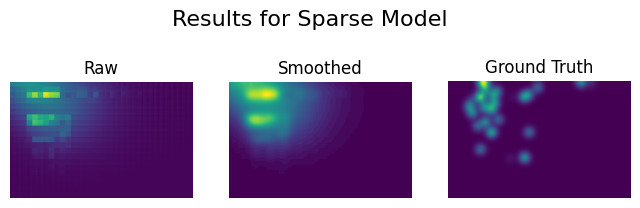

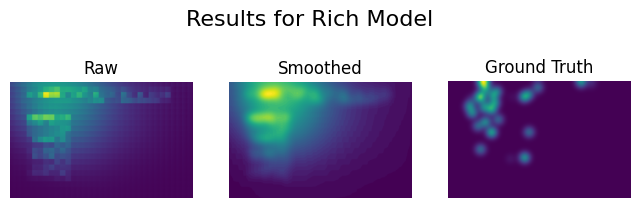

In [21]:
# Define the images that should be run / visualized:
input_image = test_images[0]
ground_truth = test_targets[0]

# Run the different models and retrieve the results:
sparse_model_output, sparse_smoothed_output = full_forward(sparse_model, input_image, patch_size)
rich_model_output, rich_smoothed_output = full_forward(rich_model, input_image, patch_size)

# Show the results:
visualize_result(sparse_model_output, sparse_smoothed_output, ground_truth, "Results for Sparse Model")
visualize_result(rich_model_output, rich_smoothed_output, ground_truth, "Results for Rich Model")